<a href="https://colab.research.google.com/github/Yan-Yamim/FATEC-API-6-SEMESTRE/blob/PK-45-us-04-incluir-nome-no-grafico-do-tam/Cria%C3%A7%C3%A3o_do_C%C3%A1lculo_TAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


## Guia: Como Adicionar Novos Dados de Concessionárias

Para adicionar e processar novos dados de concessionárias no formato `.gdb` (que presumivelmente virão compactados em um arquivo `.zip`), siga os passos abaixo:

### 1. Preparar os Novos Dados

Certifique-se de que seus novos dados estejam no formato `geodatabase` (`.gdb`) e, idealmente, compactados em um arquivo `.zip`. É importante que o nome do arquivo `.gdb` dentro do `.zip` e as camadas (layers) dentro do `.gdb` sejam consistentes com o esperado pelo script, ou você precisará ajustar o código.

### 2. Upload dos Novos Dados para o Google Drive

1.  **Acesse seu Google Drive**: Abra seu Google Drive em um navegador web.
2.  **Faça o Upload do Arquivo Zip**: Arraste e solte o seu novo arquivo `.zip` (ex: `NOVOS_DADOS_CONCESSIONARIA.gdb.zip`) para a pasta de sua escolha no Google Drive (recomenda-se a mesma pasta onde o arquivo anterior estava, `MyDrive`).
3.  **Obter o Caminho do Arquivo**: Uma vez que o arquivo está no Drive, você precisará do caminho completo para ele.
    *   Clique com o botão direito no arquivo `.zip`.
    *   Selecione 'Obter link' ou 'Detalhes' para confirmar o caminho. O caminho mais comum é `/content/drive/MyDrive/nome_do_arquivo.zip`.

### 3. Atualizar o Notebook para Ler os Novos Dados

Você precisará modificar algumas linhas de código para que o notebook aponte para o novo arquivo e, possivelmente, para novas camadas ou colunas, caso o esquema tenha mudado.

1.  **Montar o Google Drive (se ainda não o fez)**:
    *   Certifique-se de que a primeira célula que monta o Google Drive está executada:
    ```python
    from google.colab import drive
    drive.mount('/content/drive')
    ```

2.  **Atualizar o Nome do Arquivo Zip**:
    *   Localize a célula onde o `zip_filename` é definido (atualmente o cell_id `rD1SbWOQk6A2`).
    *   Modifique a variável `zip_filename` para o caminho completo do seu novo arquivo `.zip` no Google Drive.

    ```python
    zip_filename = '/content/drive/MyDrive/NOVOS_DADOS_CONCESSIONARIA.gdb.zip' # <-- ALtere este caminho
    ```

    *   Execute esta célula. Ela irá descompactar o novo `.gdb` para o diretório atual do Colab.

3.  **Verificar e Atualizar o Caminho do GDB e Nomes de Camadas/Colunas**:
    *   Localize a célula onde `gpd_path`, `layer_name` e `colunas_usadas` são definidos (atualmente o cell_id `qzgUAxYo80Jq`).
    *   **`gpd_path`**: Se o nome do arquivo `.gdb` extraído do seu novo `.zip` for diferente (por exemplo, `NOVOS_DADOS_CONCESSIONARIA.gdb`), você precisará atualizar `gpd_path`.
        ```python
        gpd_path = 'NOVOS_DADOS_CONCESSIONARIA.gdb' # <-- ALtere se o nome do arquivo .gdb mudou
        ```
    *   **`layer_name`**: Se a camada que você deseja ler dentro do novo `.gdb` tiver um nome diferente (ex: `SSDMT_NOVO`), atualize a variável `layer_name`.
        ```python
        layer_name = 'SSDMT_NOVO' # <-- ALtere se o nome da camada mudou
        ```
    *   **`colunas_usadas`**: Se as colunas que você deseja usar (`DIST`, `CTMT`, `CONJ`, `COMP`, `geometry`) tiverem nomes diferentes ou se você precisar de outras colunas, atualize a lista `colunas_usadas`.
        ```python
        colunas_usadas = ['COLUNA_DIST', 'COLUNA_CTMT', 'COLUNA_CONJ', 'COLUNA_COMP', 'geometry'] # <-- ALtere se os nomes das colunas mudaram
        ```

4.  **Executar as Células Subsequentes**:
    *   Após atualizar as variáveis, execute a célula onde `gpd.read_file` é chamado (`qzgUAxYo80Jq`) e todas as células subsequentes. O notebook agora processará os novos dados.

### Observações Importantes

*   **Consistência dos Dados**: O script atual espera certas colunas (`DIST`, `CTMT`, `CONJ`, `COMP`, `geometry`) e realiza operações específicas como a conversão de `COMP` para numérico e cálculo de `COMP_KM`. Se a estrutura dos seus novos dados for significativamente diferente, o código de processamento (ex: `gdf['COMP'] = pd.to_numeric(...)`) também precisará ser adaptado.
*   **Pyogrio Engine**: O uso de `engine='pyogrio'` é para otimizar a leitura de arquivos `.gdb`. Certifique-se de que ele está funcionando corretamente ou considere o uso do engine padrão se houver problemas (`engine=None`).
*   **Verificação de Erros**: Preste atenção a quaisquer mensagens de erro após a execução das células, especialmente aquelas relacionadas a arquivos não encontrados ou colunas ausentes. Isso indicará que você precisa ajustar os caminhos ou nomes de colunas/camadas.

In [2]:
import zipfile
import os

zip_filename = (
    '/content/drive/MyDrive/ENEL_GO_6072_2023-04-30_V11_20240201-0941.gdb.zip'
)

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall('.')

    print(f'Arquivo {zip_filename} descompactado com sucesso.')
    print(f'Conteúdo do diretório atual após descompactar: {os.listdir()}')
else:
    print(
        f'Erro: O arquivo zip {zip_filename} não foi encontrado. Certifique-se de que o caminho no Google Drive está correto e que o Drive foi montado.'
    )

Arquivo /content/drive/MyDrive/ENEL_GO_6072_2023-04-30_V11_20240201-0941.gdb.zip descompactado com sucesso.
Conteúdo do diretório atual após descompactar: ['.config', 'ENEL_GO_6072_2023-04-30_V11_20240201-0941.gdb', 'drive', 'sample_data']


In [3]:
import geopandas as gpd
import pandas as pd
import os

gpd_path = 'ENEL_GO_6072_2023-04-30_V11_20240201-0941.gdb'

layer_name_ssdmt = 'SSDMT'
layer_name_ctmt = 'CTMT'
colunas_ssdmt = ['COD_ID', 'DIST', 'CTMT', 'CONJ', 'COMP', 'geometry']
colunas_ctmt = ['COD_ID', 'NOME']

if not os.path.exists(gpd_path):
    print(
        f"Erro: O arquivo '{gpd_path}' não foi encontrado. Por favor, verifique se o caminho no Google Drive está correto e que o Drive foi montado."
    )
    print('Arquivos disponíveis no diretório atual:')
    print(os.listdir('/content'))
else:
    gdf = gpd.read_file(
        gpd_path,
        layer=layer_name_ssdmt,
        columns=colunas_ssdmt,
        engine='pyogrio',
    )

    gdf_ctmt = gpd.read_file(
        gpd_path, layer=layer_name_ctmt, columns=colunas_ctmt, engine='pyogrio'
    )

    gdf_ctmt_unique = gdf_ctmt[['COD_ID', 'NOME']].drop_duplicates(
        subset=['COD_ID']
    )
    gdf = pd.merge(
        gdf,
        gdf_ctmt_unique,
        left_on='CTMT',
        right_on='COD_ID',
        how='left',
        suffixes=('_ssdmt', '_ctmt'),
    )

    gdf = gdf.drop(columns='COD_ID_ctmt')
    gdf = gdf.rename(columns={'COD_ID_ssdmt': 'COD_ID'})

    gdf['COMP'] = pd.to_numeric(gdf['COMP'], errors='coerce')
    gdf['COMP_KM'] = gdf['COMP'] / 1000

    calculo_trechos = (
        gdf
        .groupby(['DIST', 'CONJ', 'CTMT', 'NOME'])['COMP_KM']
        .sum()
        .reset_index()
    )

    print('\nResumo de Extensão de Rede MT (em Km):')
    print(calculo_trechos.head())


Resumo de Extensão de Rede MT (em Km):
   DIST  CONJ     CTMT                          NOME   COMP_KM
0  6072     0  5000970  MOZARLANDIA (TRANSMISSAO)-31  0.909090
1  6072     0  5007020                    ANICUNS-99  0.006578
2  6072     0  5007061                    JUSSARA-99  0.008501
3  6072     0  5009477                   APARECIDA-1  0.008741
4  6072     0  5009478                   APARECIDA-2  0.216269


In [4]:
ranking_por_conjunto = (
    calculo_trechos.groupby(['CONJ', 'NOME'])['COMP_KM'].sum().reset_index()
)
ranking_top_10_conjunto = ranking_por_conjunto.sort_values(
    by='COMP_KM', ascending=False
).head(10)

display(ranking_top_10_conjunto)

,CONJ,NOME,COMP_KM
293,14916,SAO DOMINGOS-31,2880.248893
876,16494,NIQUELANDIA 69KV-31,2396.748792
169,14881,CAIAPONIA-32,2304.865579
499,14963,PORANGATU-33,2234.945246
283,14911,GOIAS-31,1999.517214
507,14964,QUIRINOPOLIS-99,1956.368079
728,15748,PIRES DO RIO-33,1878.906372
321,14923,IPORA-32,1839.037461
382,14939,MARA ROSA-31,1817.920699
155,14879,CACHOEIRA ALTA-35,1805.522295


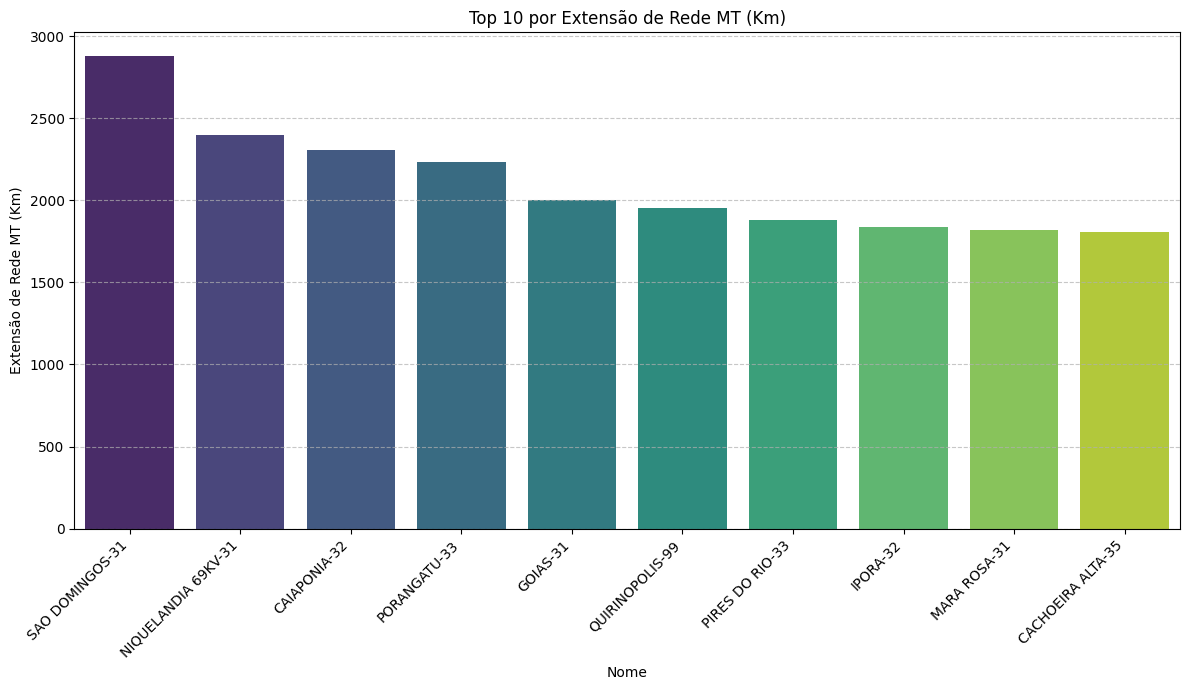

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

if ranking_top_10_conjunto.empty or len(ranking_top_10_conjunto) < 10:
    print(
        'Não há dados suficientes ou o ranking Top 10 está vazio para gerar o gráfico.'
    )
else:
    plt.figure(figsize=(12, 7))
    sns.barplot(
        x='NOME',
        y='COMP_KM',
        data=ranking_top_10_conjunto,
        palette='viridis',
        hue='NOME',
        legend=False,
    )
    plt.title('Top 10 por Extensão de Rede MT (Km)')
    plt.xlabel('Nome')
    plt.ylabel('Extensão de Rede MT (Km)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()